In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('./custom_functions')
import pandas as pd
import numpy as np
import griess as gr
import bmgdata as bd
import glob
import denitfit as dn
import pickle
import matplotlib.pyplot as plt
import importlib

# figure size and font size
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (20, 12),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
pylab.rcParams.update(params)

In [2]:
filepath = '20250114'

## 1. Standard curves with griess assay

### (1) NO2 before VCl treatment

20250114/standard_metadata.csv
None
20250114/20250125_Ik_STD_NO2_540.CSV
20250114/20250125_Ik_STD_NO2_900.CSV
20250114/20250125_Ik_STD_NO2NO3_540.CSV
20250114/20250125_Ik_STD_NO2NO3_900.CSV
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []
returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0673           0.0166   -4.0562    0.0002
1        2.5290           0.0309   81.9413    0.0000
2       -0.2335           0.0081  -28.9027    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn 

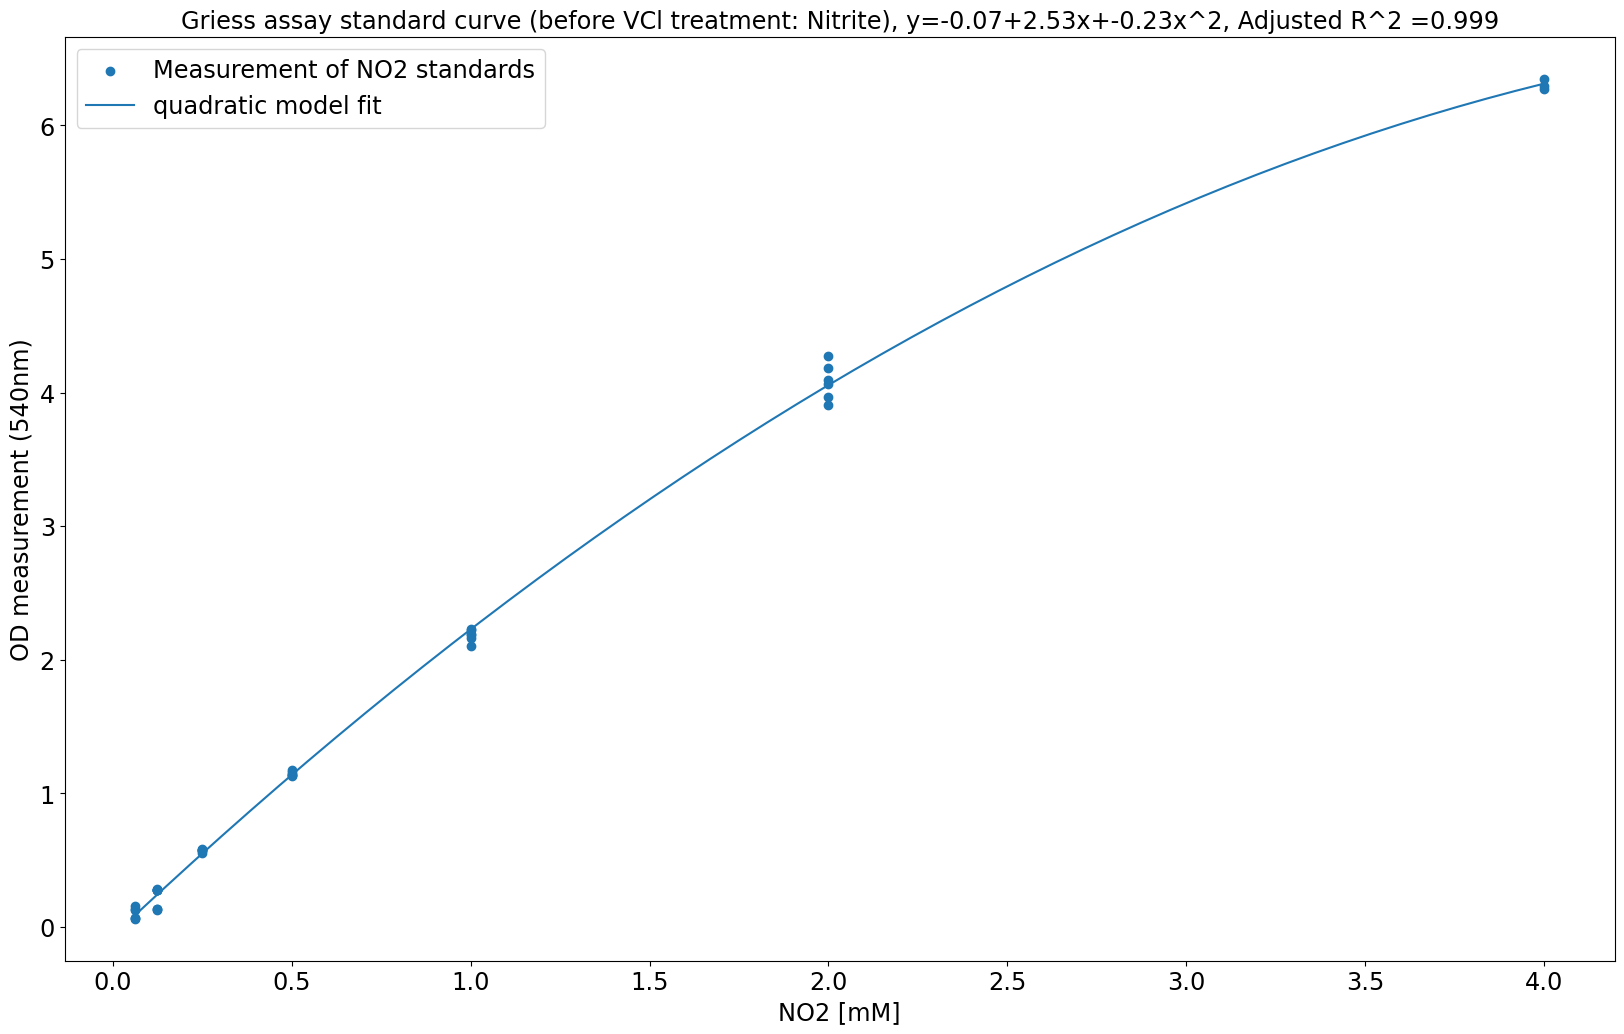

In [4]:
#fit griess assay model using standard curves
std_meta_fn = f"{filepath}/standard_metadata.csv"
print(std_meta_fn)
std_no2_fn = None
print(std_no2_fn)
std_no2_540_fn = glob.glob(f"{filepath}/*_Ik_STD_NO2_540*")[0]
print(std_no2_540_fn)
std_no2_900_fn = glob.glob(f"{filepath}/*_Ik_STD_NO2_900*")[0]
print(std_no2_900_fn)

std_no2no3_fn = None
std_no2no3_540_fn = glob.glob(f"{filepath}/*_Ik_STD_NO2NO3_540*")[0]
print(std_no2no3_540_fn)
std_no2no3_900_fn = glob.glob(f"{filepath}/*_Ik_STD_NO2NO3_900*")[0]
print(std_no2no3_900_fn)

# plot standard curve
gr.plot_griess_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'{filepath}/plots/standard_no2.png')

# fitted parameters
fit_list = gr.fit_griess(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
[[no2_blank,no2no3_blank], g_fit, v_fit, no3_fit] = fit_list


Load standard curve

### (2) NO3 after VCl treatment

[np.float64(-0.06391545210915983), np.float64(2.205935323138269), np.float64(-0.18235953926443887)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0639           0.0282   -2.2632    0.0355
1        2.2059           0.0493   44.7643    0.0000
2       -0.1824           0.0119  -15.2789    0.0000


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          1.145e+04
Dat

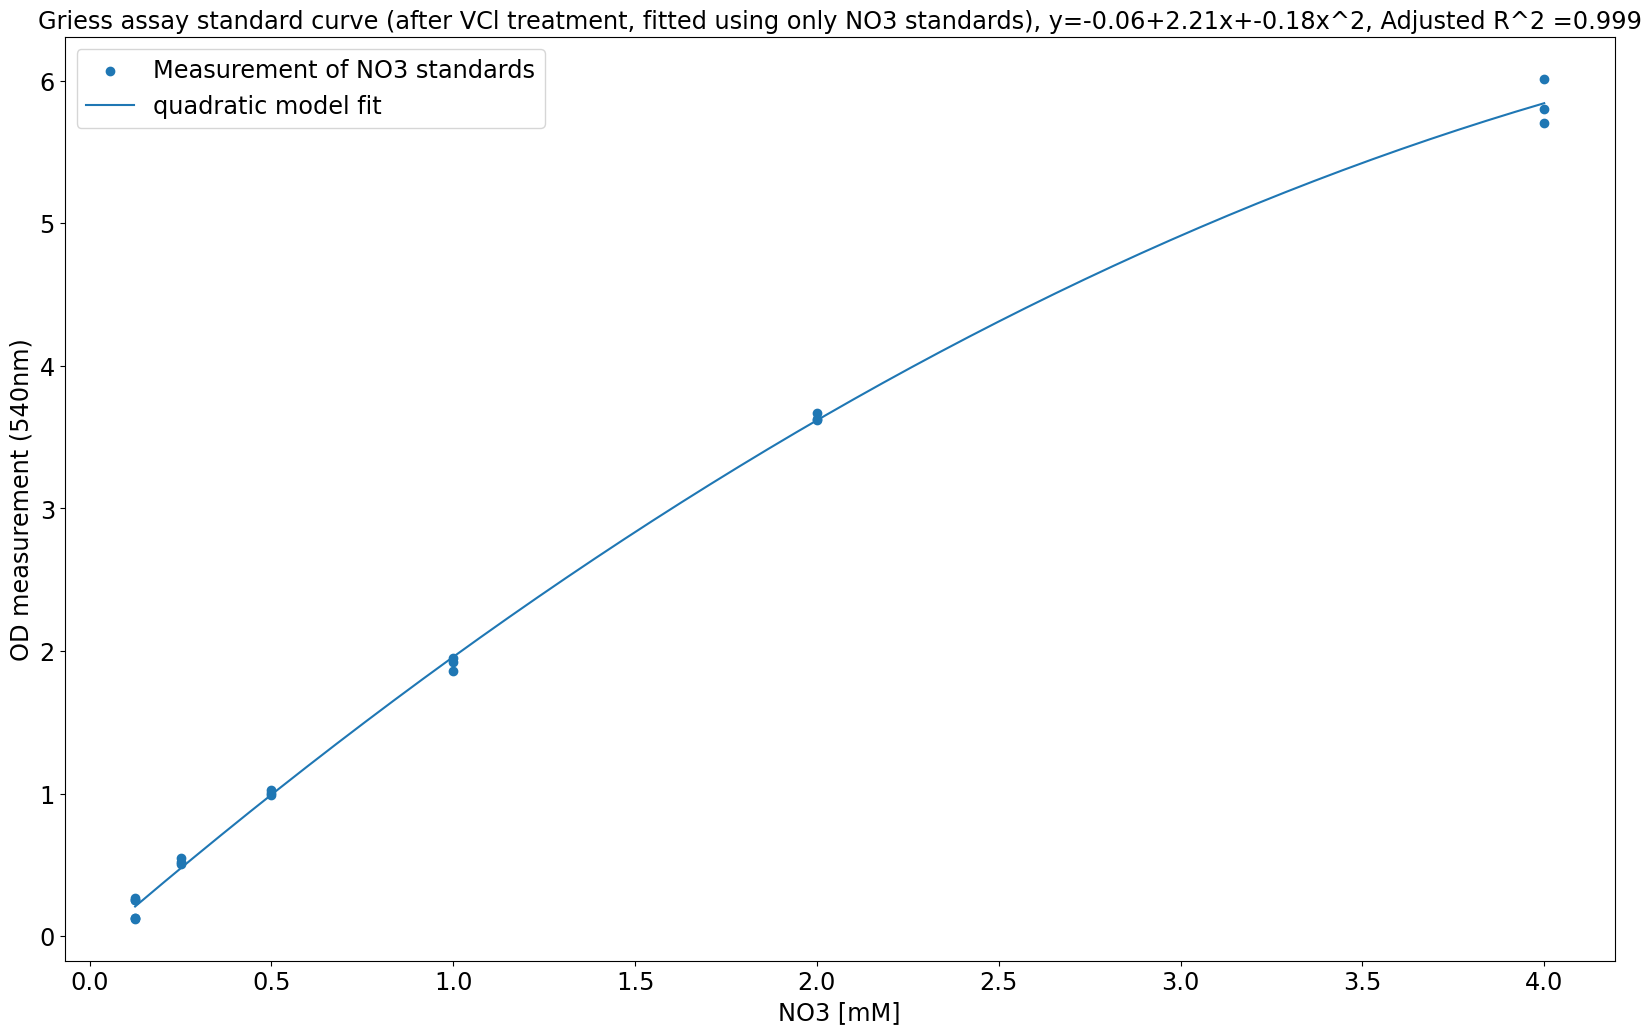

In [5]:
print(no3_fit)

gr.plot_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'{filepath}/plots/standard_no3.png')

### (3) NO2+NO3 after VCl treatment

[np.float64(-0.07556490857480935), np.float64(2.286335125781852), np.float64(-0.1946270233724697)]
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


 (From sklearn LinearRegression) Manual calculation of p-value. Here we use sklearn LinearRegression package
   Coefficients  Standard Errors  t values  P-Values
0       -0.0756           0.0134   -5.6542       0.0
1        2.2863           0.0233   98.0406       0.0
2       -0.1946           0.0056  -34.4582       0.0


 (From statsmodel package) Coefficients are a bit different from the sklearn LinearRegression package
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          4.719e+04
Date

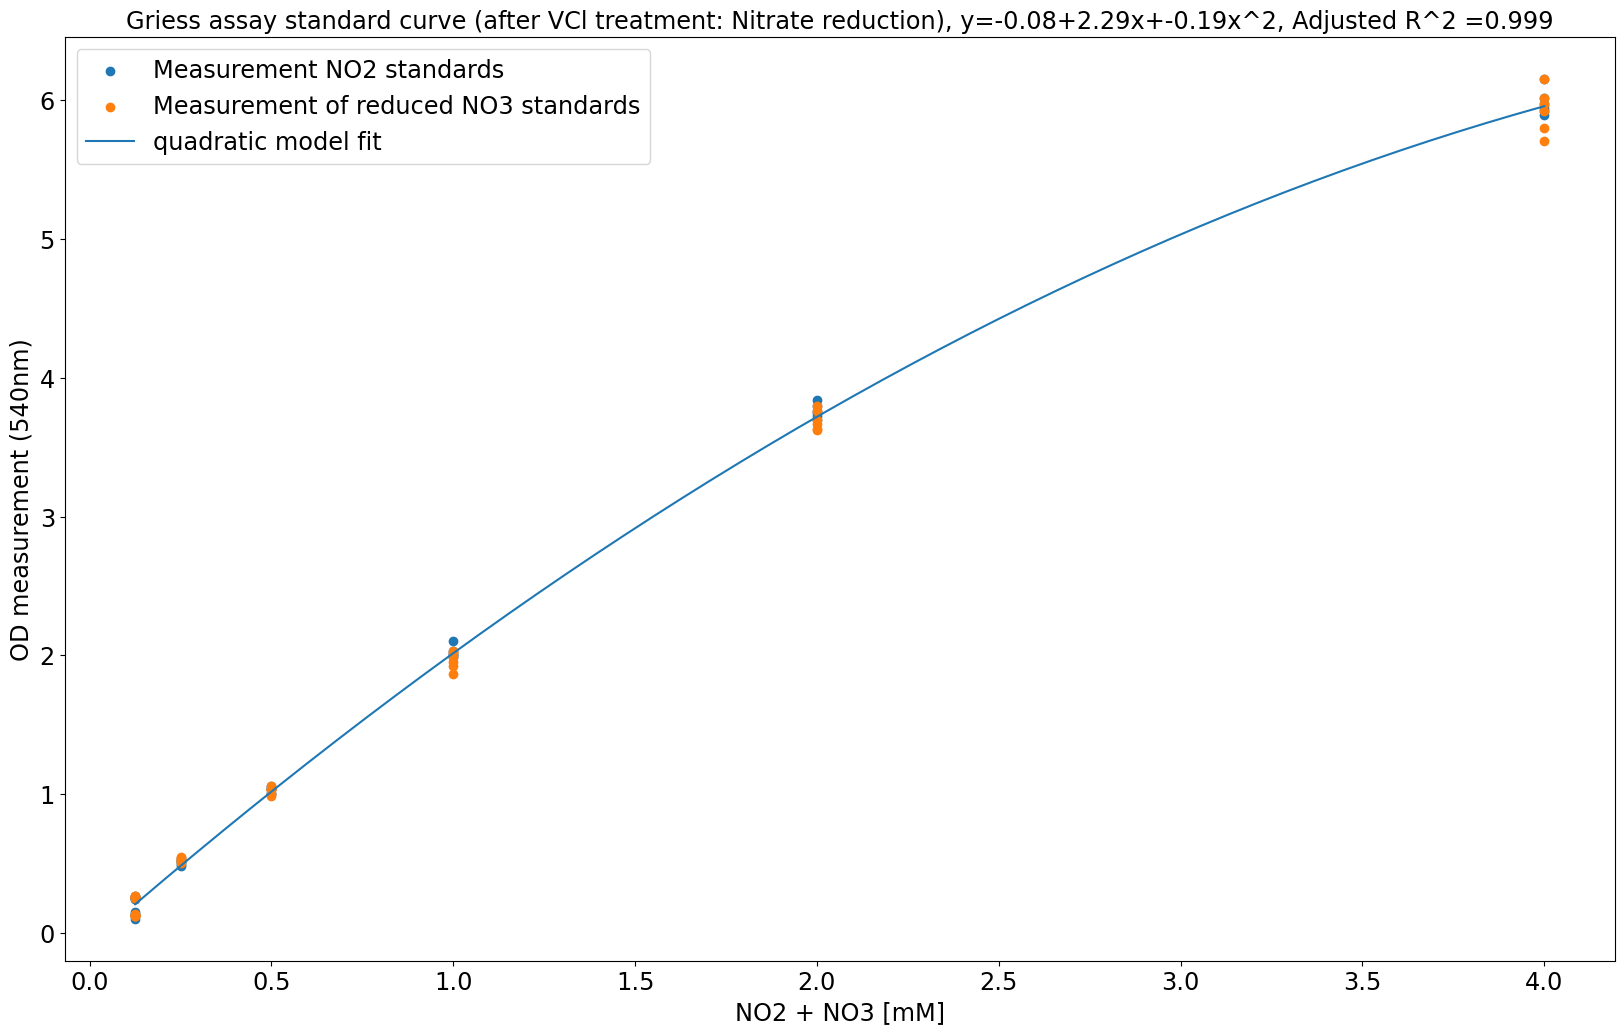

In [6]:
plt.cla()
print(v_fit)

gr.plot_vcl_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'{filepath}/plots/standard_no2no3.png')

### (4) ??? Checking the known concentration and the predicted concentration of the NO2-, NO3- mixed standards

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


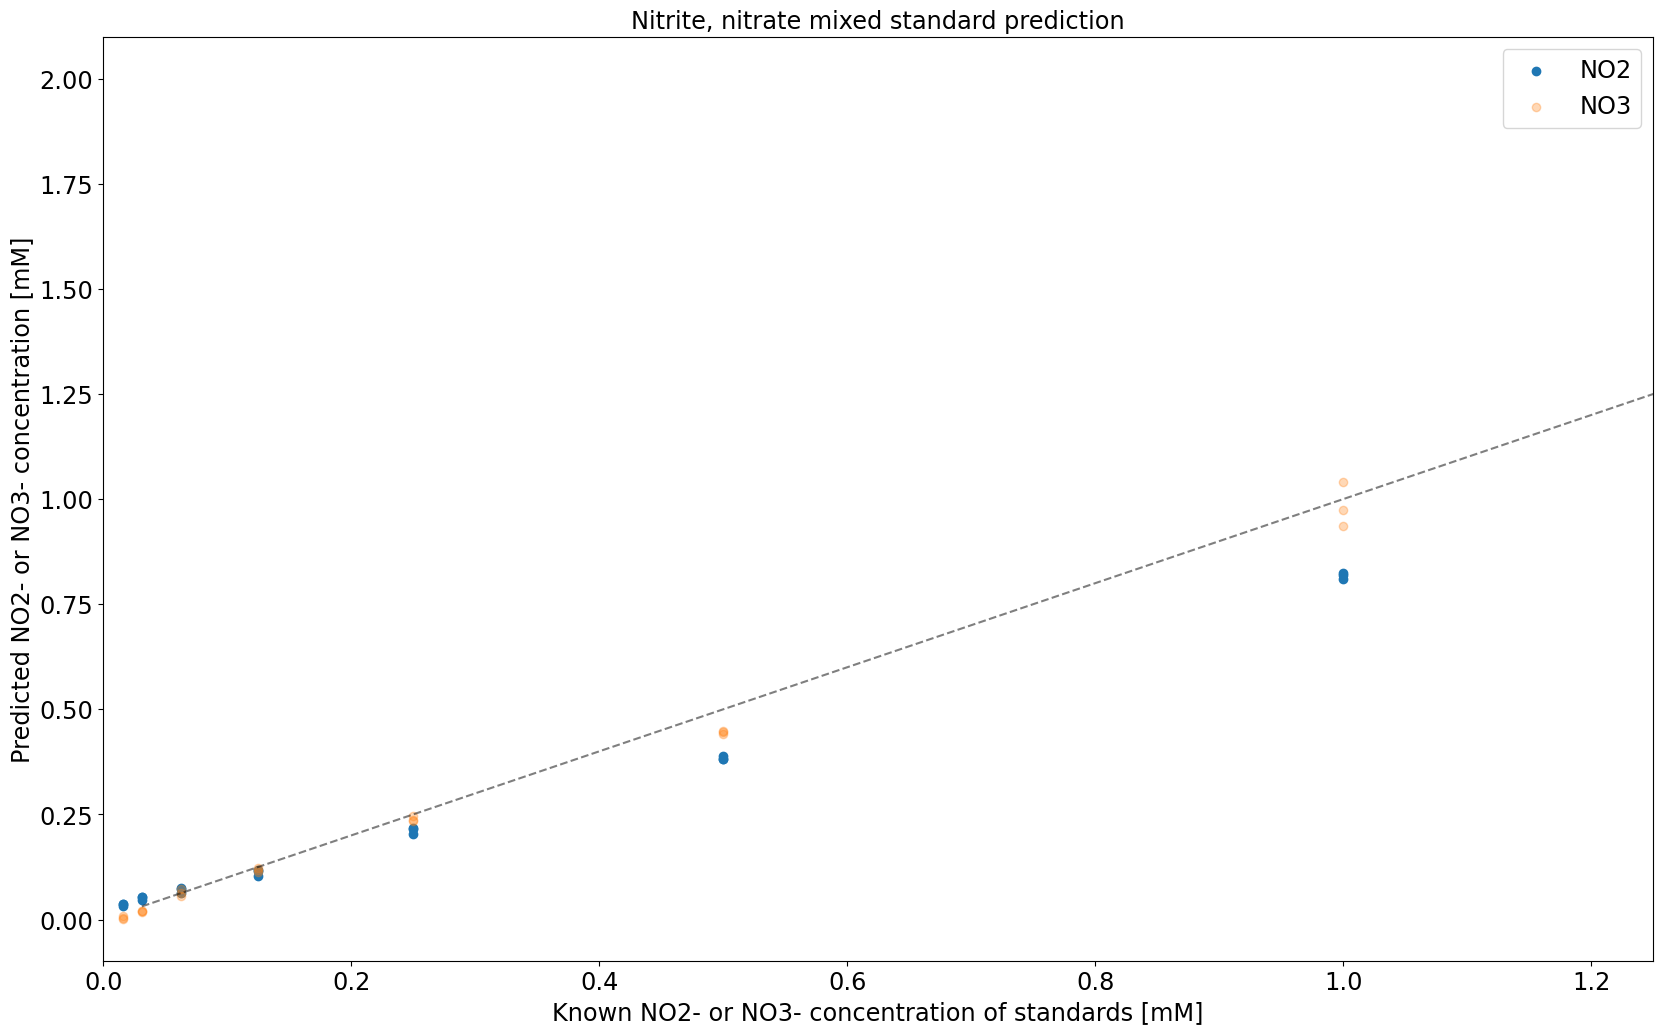

In [10]:
# check mixed conditions prediction
importlib.reload(dn)
gr.plot_mixed_standard_predict(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'{filepath}/plots/standard_no2no3_mixed.png')

### (5) ???

returns true for elements more than 1.5 interquartile ranges above the upper quartile
returns true for elements more than 1.5 interquartile ranges above the upper quartile
These wells had NaN values:  []


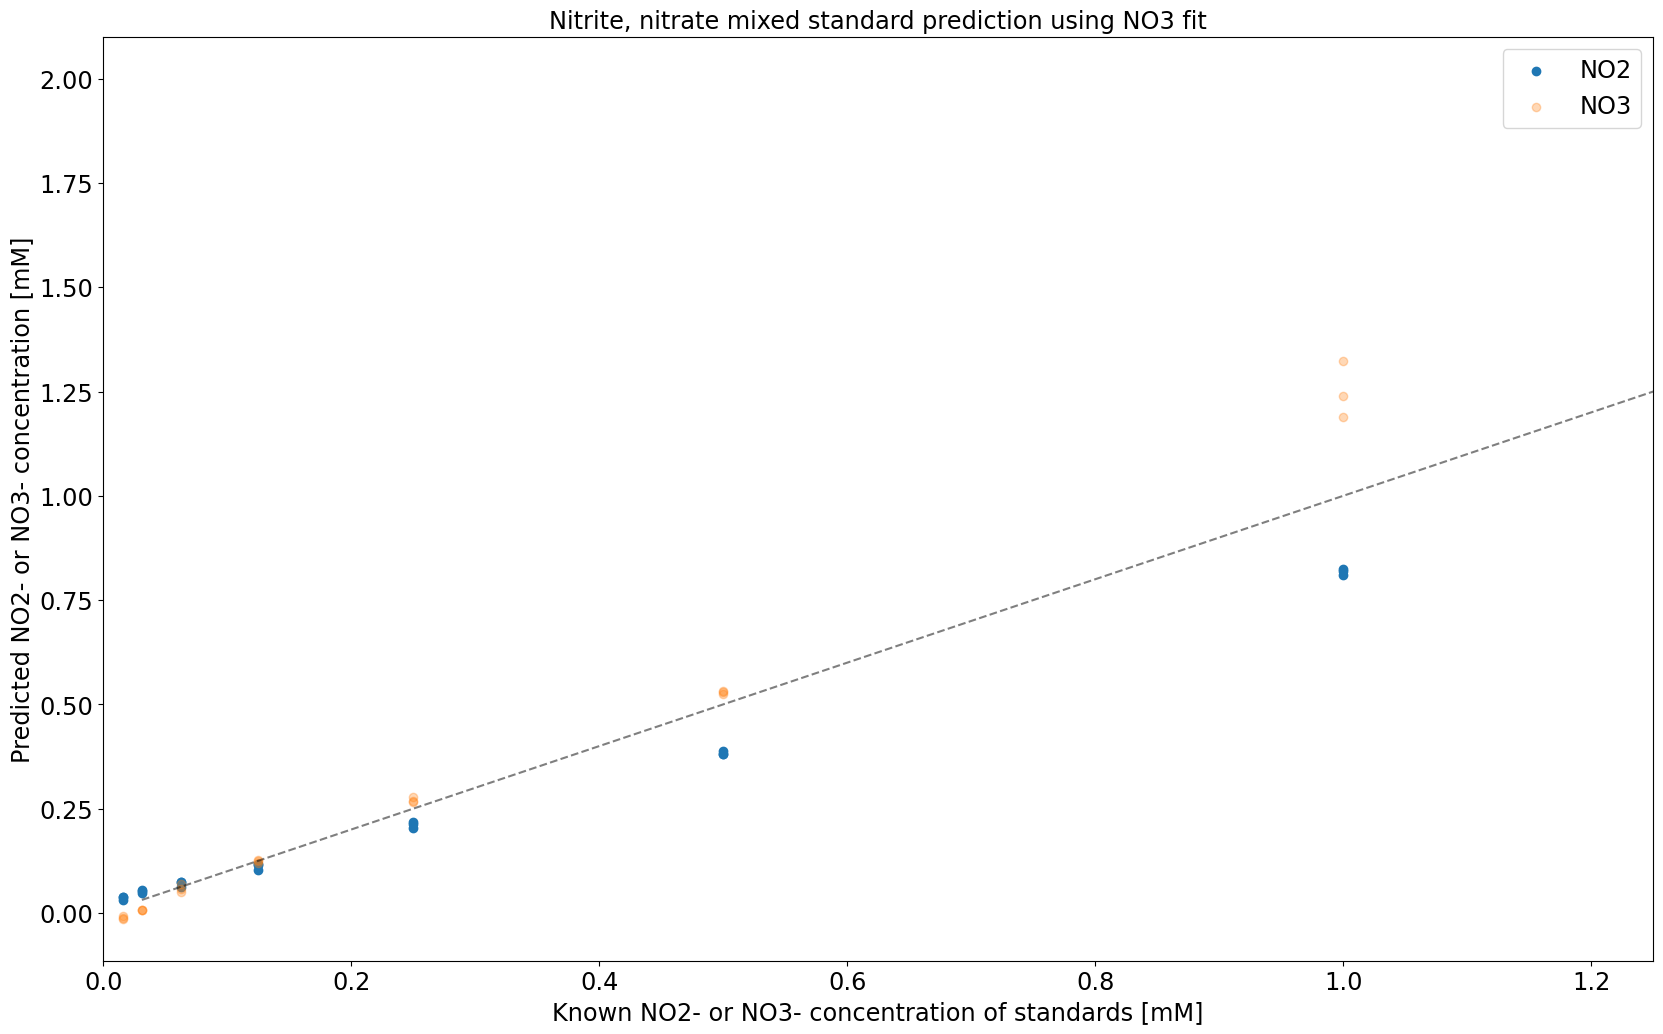

In [12]:
gr.plot_mixed_standard_predict_with_no3_fit(meta_fn = std_meta_fn, no2_fn = std_no2_fn, no2_540_fn=std_no2_540_fn, no2_900_fn=std_no2_900_fn, no2no3_fn=None, no2no3_540_fn = std_no2no3_540_fn, no2no3_900_fn = std_no2no3_900_fn)
plt.savefig(f'{filepath}/plots/standard_.png')

## Make sure that the wellscan is removing all outliers from our data.

In [13]:
%pip install openpyxl

for i in [0,1,2,3,4,5,6,7,8]:
    AW_plate1_2_T0_meta_fn = "20241103/sample_metadata.csv"
    print(AW_plate1_2_T0_meta_fn)
    AW_plate1_2_T0_no2_fn = None
    print(AW_plate1_2_T0_no2_fn)
    AW_plate1_2_T0_no2_540_fn = glob.glob(f"20241103/*_NO2_tp{i}_540*")[0]
    print(AW_plate1_2_T0_no2_540_fn)
    AW_plate1_2_T0_no2_900_fn = glob.glob(f"20241103/*_NO2_tp{i}_900*")[0]
    print(AW_plate1_2_T0_no2_900_fn)
    AW_plate1_2_T0_no2no3_fn = None
    print(AW_plate1_2_T0_no2no3_fn)
    AW_plate1_2_T0_no2no3_540_fn = glob.glob(f"20241103/*_NO2NO3_tp{i}_540*")[0]
    print(AW_plate1_2_T0_no2no3_540_fn)
    AW_plate1_2_T0_no2no3_900_fn = glob.glob(f"20241103/*_NO2NO3_tp{i}_900*")[0]
    print(AW_plate1_2_T0_no2no3_900_fn)

    gr.get_concentration_xlsx(excel_output = f"20241103/griess_{i}.xlsx",
                                no2_blank = no2_blank, no2no3_blank = no2no3_blank, g_fit = g_fit, v_fit = no3_fit, 
                            meta_fn = AW_plate1_2_T0_meta_fn, no2_fn=None, no2_540_fn = AW_plate1_2_T0_no2_540_fn, no2_900_fn = AW_plate1_2_T0_no2_900_fn, no2no3_fn=None, no2no3_540_fn=AW_plate1_2_T0_no2no3_540_fn, no2no3_900_fn=AW_plate1_2_T0_no2no3_900_fn)
    
    print("--------------------------------------------------------------------------------------------------------------")

        

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
20241103/sample_metadata.csv
None


IndexError: list index out of range